# Análisis de cráteres — Luna

Este notebook realiza el análisis exploratorio completo del dataset de cráteres lunares.

**Orden de ejecución:** ejecuta las celdas de arriba hacia abajo.

In [1]:
# ── 1. Importaciones ──────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader          import cargar_dataset
from src.preprocessor         import preprocesar_dataset
from src.stats_analyzer       import estadisticas_descriptivas, generar_histogramas, matriz_correlacion
from src.correlation_analyzer import scatter_plot
from src.plot_generator       import panel_resumen
from src.map_builder          import construir_mapa_luna

In [2]:
# ── 2. Carga del dataset ──────────────────────────────────────────────────
# Ajusta la ruta al fichero CSV según tu entorno
df_luna = cargar_dataset('../data/luna_crateres.csv', planeta='luna')
df_luna.head()

[OK] Dataset 'luna' cargado desde '../data/luna_crateres.csv'.
     Registros: 1,296,796  |  Columnas: 21


,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
0,00-1-000000,-19.83040,264.7570,-19.89050,264.6650,940.960,21.31790,975.874,905.968,0.371666,...,35.9919,0.007888,0.008424,0.636750,0.560417,0.373749,0.002085,0.000968,0.568712,8088
1,00-1-000001,44.77630,328.6020,44.40830,329.0460,249.840,5.99621,289.440,245.786,0.528111,...,127.0030,0.011178,0.015101,1.052780,0.209035,0.357296,0.005100,0.004399,0.627328,2785
2,00-1-000002,57.08660,82.0995,56.90000,81.6464,599.778,21.57900,632.571,561.435,0.460721,...,149.1620,0.008464,0.019515,0.776149,0.747352,0.374057,0.003095,0.002040,0.492373,5199
3,00-1-000003,1.96124,230.6220,1.95072,230.5880,558.762,14.18190,568.529,546.378,0.276416,...,133.6910,0.007079,0.007839,0.526945,0.532872,1.262710,0.004496,0.001400,0.595221,4341
4,00-1-000004,-49.14960,266.3470,-49.18330,266.3530,654.332,17.50970,665.240,636.578,0.290365,...,87.6468,0.008827,0.017733,0.568958,0.758631,1.383530,0.004626,0.001533,0.545924,5933


In [3]:
# ── 3. Preprocesamiento ───────────────────────────────────────────────────
df_luna = preprocesar_dataset(df_luna, planeta='luna')
df_luna.head()

[OK] Preprocesamiento completado para 'luna'.
     Registros válidos: 1,296,796  (eliminados por nulos: 0)


,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG,log_diam
0,00-1-000000,-19.83040,264.7570,-19.89050,264.6650,940.960,21.31790,975.874,905.968,0.371666,...,0.007888,0.008424,0.636750,0.560417,0.373749,0.002085,0.000968,0.568712,8088,6.847963
1,00-1-000001,44.77630,328.6020,44.40830,329.0460,249.840,5.99621,289.440,245.786,0.528111,...,0.011178,0.015101,1.052780,0.209035,0.357296,0.005100,0.004399,0.627328,2785,5.524815
2,00-1-000002,57.08660,82.0995,56.90000,81.6464,599.778,21.57900,632.571,561.435,0.460721,...,0.008464,0.019515,0.776149,0.747352,0.374057,0.003095,0.002040,0.492373,5199,6.398225
3,00-1-000003,1.96124,230.6220,1.95072,230.5880,558.762,14.18190,568.529,546.378,0.276416,...,0.007079,0.007839,0.526945,0.532872,1.262710,0.004496,0.001400,0.595221,4341,6.327512
4,00-1-000004,-49.14960,266.3470,-49.18330,266.3530,654.332,17.50970,665.240,636.578,0.290365,...,0.008827,0.017733,0.568958,0.758631,1.383530,0.004626,0.001533,0.545924,5933,6.485142


In [4]:
# ── 4. Estadísticas descriptivas ──────────────────────────────────────────
variables = ['DIAM_CIRC_IMG', 'ARC_IMG', 'PTS_RIM_IMG', 'log_diam']
estadisticas_descriptivas(df_luna, variables)

,DIAM_CIRC_IMG,ARC_IMG,PTS_RIM_IMG,log_diam
count,1.296796e+06,1.296796e+06,1.296796e+06,1.296796e+06
mean,2.436963e+00,8.617298e-01,1.837816e+01,1.088204e+00
std,5.519133e+00,1.346495e-01,3.143630e+01,4.232134e-01
min,1.000000e+00,2.757060e-02,6.000000e+00,6.931472e-01
25%,1.242710e+00,7.644240e-01,1.100000e+01,8.076850e-01
50%,1.606840e+00,8.383095e-01,1.300000e+01,9.581388e-01
75%,2.380860e+00,1.000000e+00,1.800000e+01,1.218130e+00
max,2.491870e+03,1.000000e+00,8.088000e+03,7.821190e+00


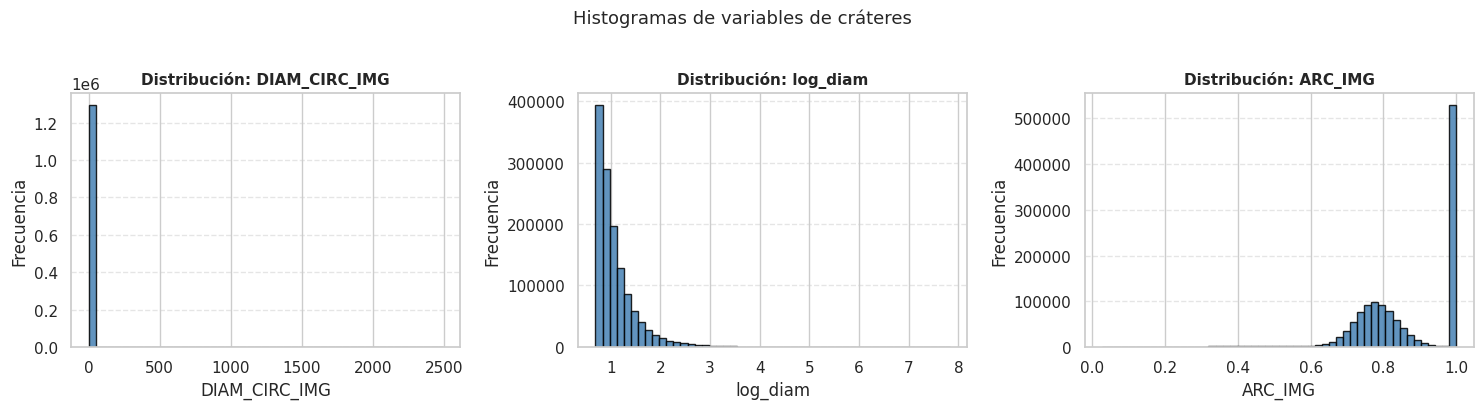

In [5]:
# ── 5. Histogramas de distribución ────────────────────────────────────────
generar_histogramas(df_luna, ['DIAM_CIRC_IMG', 'log_diam', 'ARC_IMG'])

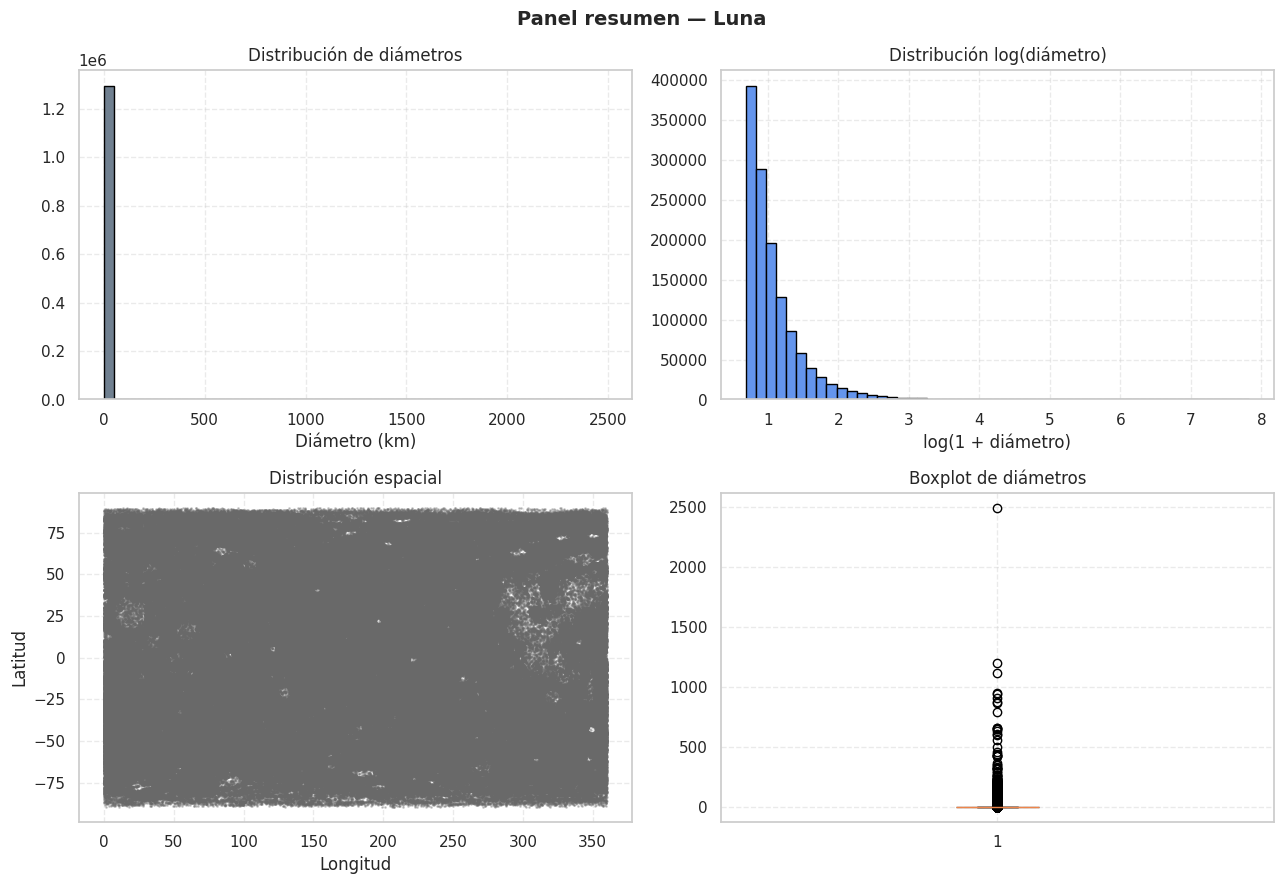

In [6]:
# ── 6. Panel resumen ──────────────────────────────────────────────────────
panel_resumen(df_luna, planeta='luna')

In [7]:
# ── 7. Mapa interactivo ───────────────────────────────────────────────────
mapa_luna = construir_mapa_luna(df_luna, max_crateres=500)
mapa_luna  # Mostrar el mapa inline

[OK] Mapa lunar generado con 500 cráteres.


In [8]:
# ── 8. Exportar mapa a HTML ───────────────────────────────────────────────
mapa_luna.save('mapa_luna.html')
print('Mapa exportado a mapa_luna.html')

Mapa exportado a mapa_luna.html
